<a href="https://colab.research.google.com/github/juleskantzer/kaggle/blob/main/s6/s6e1_Student_Test_Scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import gdown
import pandas as pd

# Create the directory for storing files
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Google Drive file IDs (replace with actual IDs)
TRAIN_FILE_ID = "1Pg7Unltwg29J90fLl6BfutiRtrgpn2yC"
TEST_FILE_ID = "1pbmwqwqAdCu1QmCOzQdXSaSvvu6sIY1I"

# File paths
train_output = os.path.join(DATA_DIR, "train.csv")
test_output = os.path.join(DATA_DIR, "test.csv")

# Download train.csv
print("📥 Downloading train.csv...")
gdown.download(f"https://drive.google.com/uc?id={TRAIN_FILE_ID}", train_output, quiet=False)

# Download test.csv
print("📥 Downloading test.csv...")
gdown.download(f"https://drive.google.com/uc?id={TEST_FILE_ID}", test_output, quiet=False)

# Load into Pandas DataFrame
print("📊 Loading data into DataFrames...")
df_train = pd.read_csv(train_output,index_col="id")
df_test = pd.read_csv(test_output,index_col="id")

# Confirm shapes
print("\n✅ Files downloaded successfully!")
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

📥 Downloading train.csv...


Downloading...
From: https://drive.google.com/uc?id=1Pg7Unltwg29J90fLl6BfutiRtrgpn2yC
To: /content/data/train.csv
100%|██████████| 46.0M/46.0M [00:00<00:00, 53.1MB/s]


📥 Downloading test.csv...


Downloading...
From: https://drive.google.com/uc?id=1pbmwqwqAdCu1QmCOzQdXSaSvvu6sIY1I
To: /content/data/test.csv
100%|██████████| 18.4M/18.4M [00:00<00:00, 41.2MB/s]


📊 Loading data into DataFrames...

✅ Files downloaded successfully!
Train shape: (630000, 12)
Test shape: (270000, 11)


# Exploration data analysis


In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 62.5+ MB


- no null values
- 5 int 7 strings

In [4]:
df_train.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


- High school Class
- Notation max 100
- some data are per/day


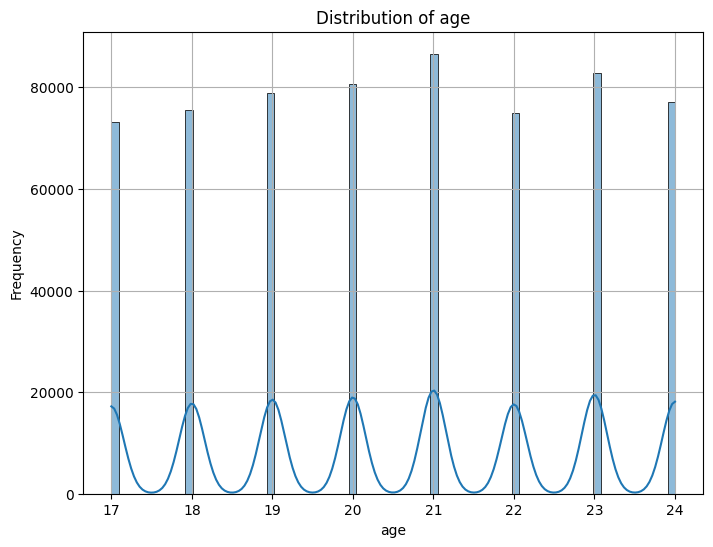

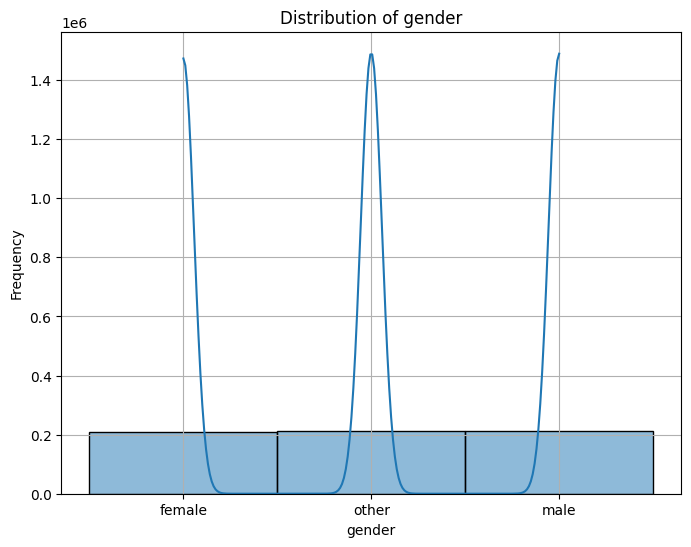

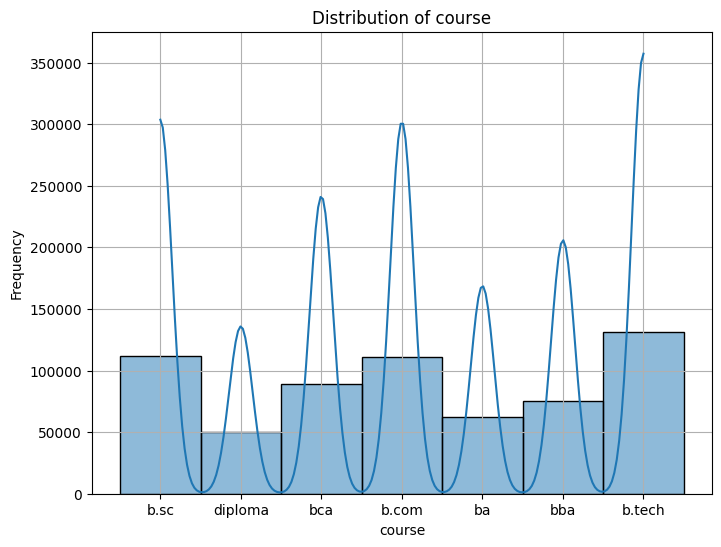

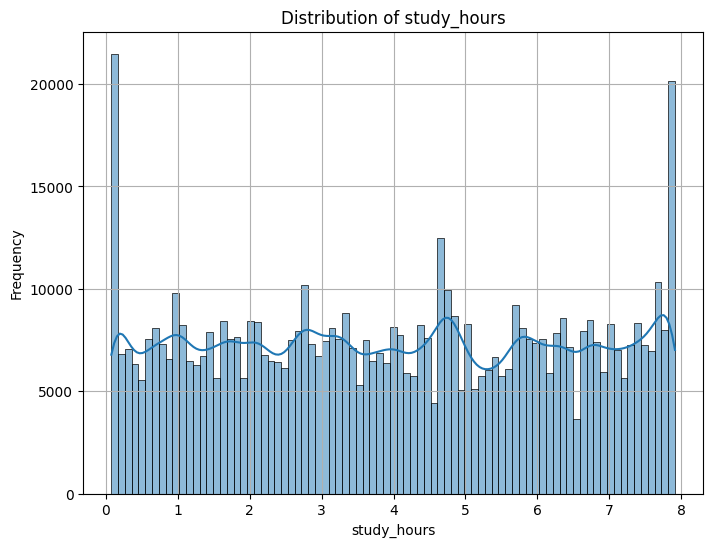

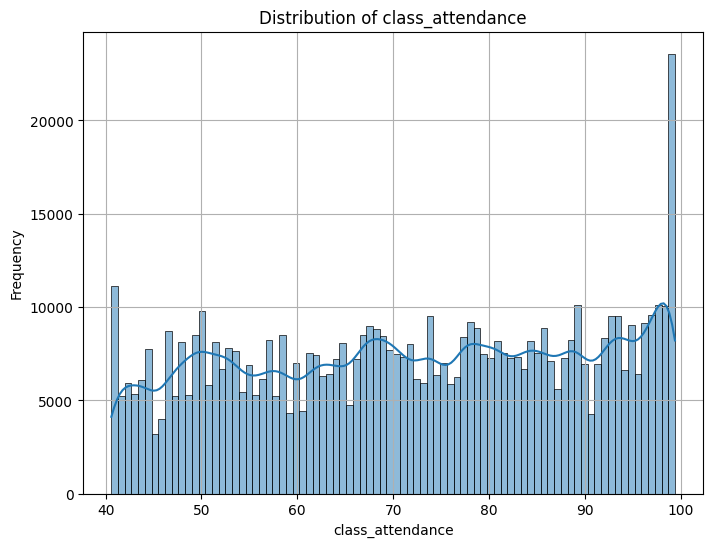

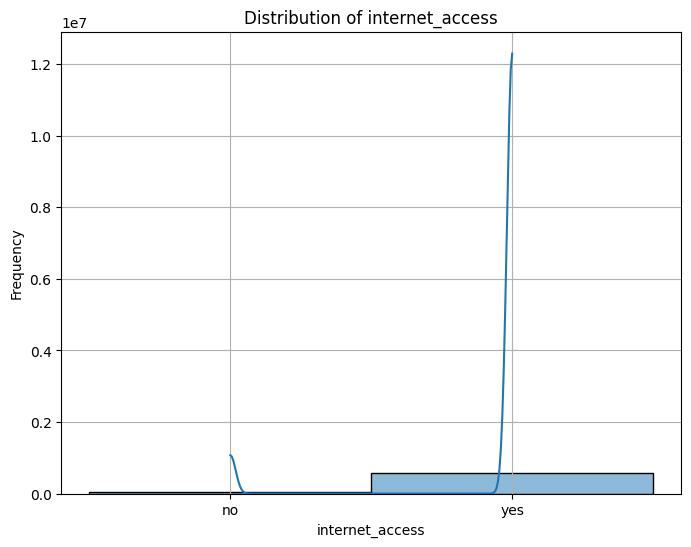

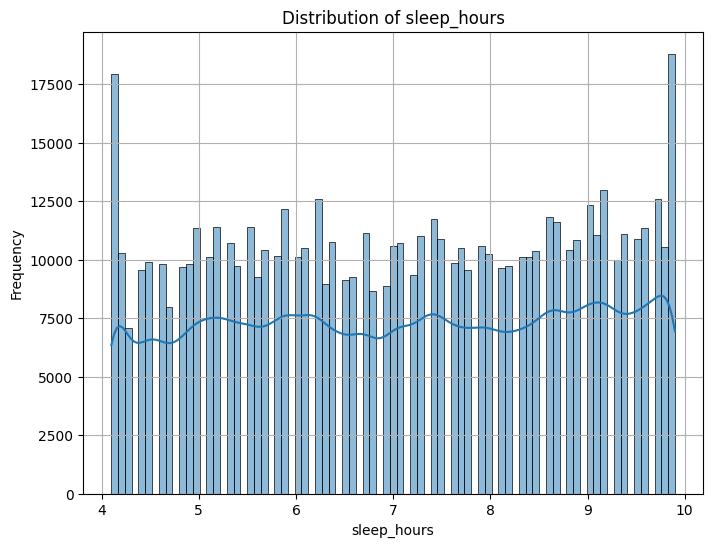

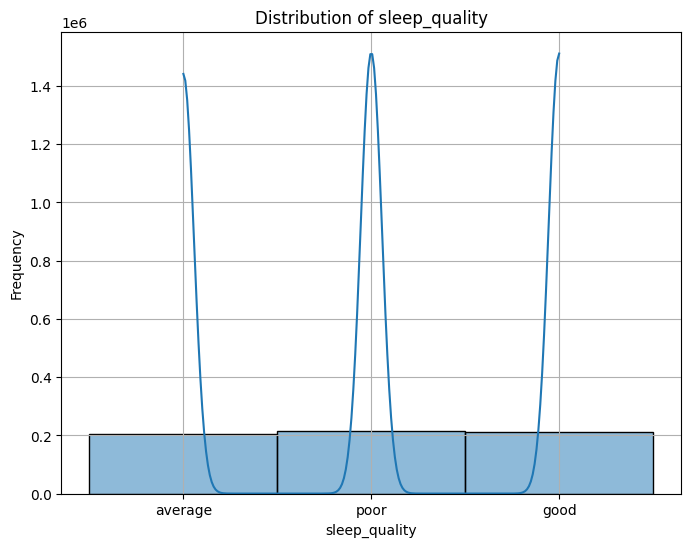

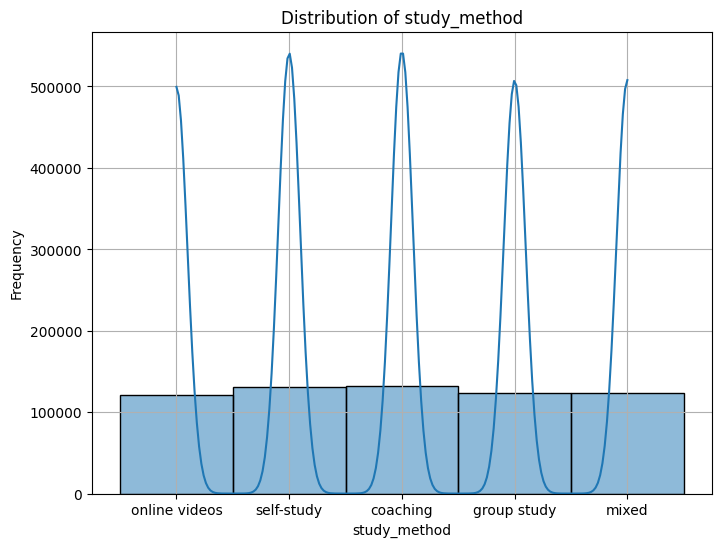

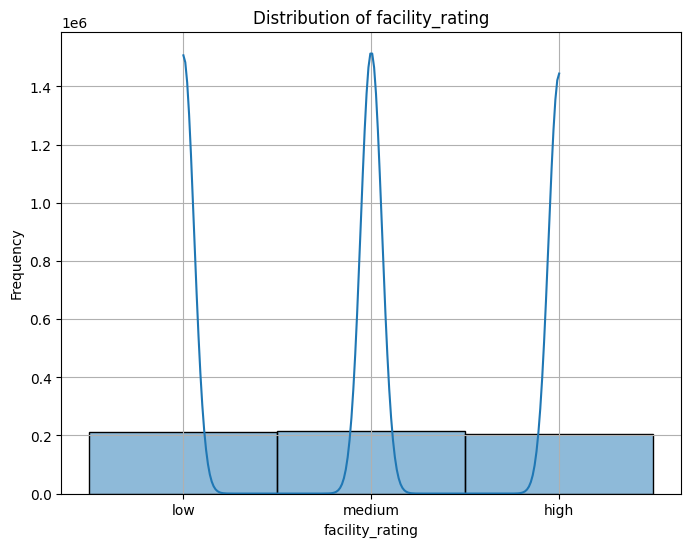

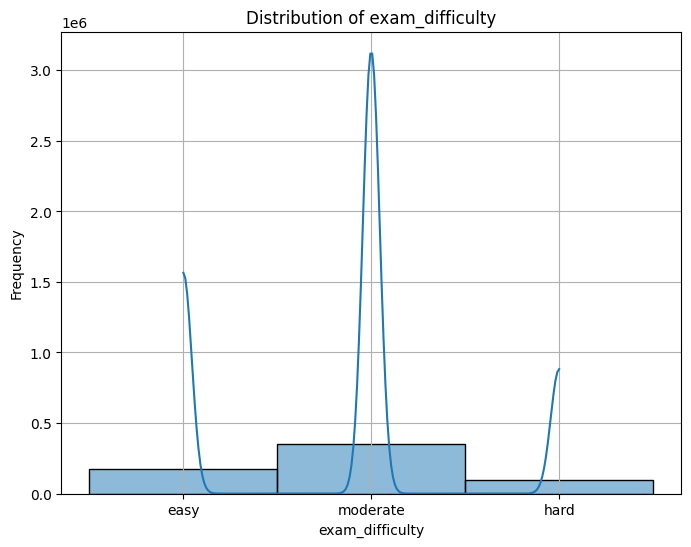

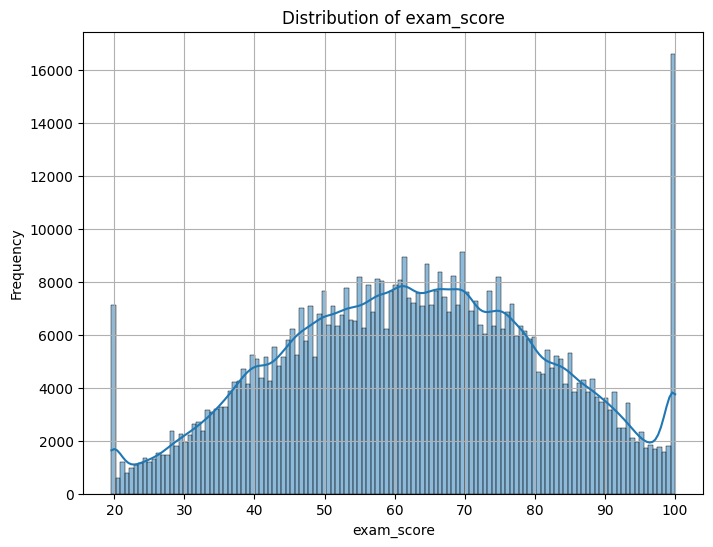

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df_train.columns:
   plt.figure(figsize=(8, 6))
   sns.histplot(df_train[col], kde=True)
   plt.title(f'Distribution of {col}')
   plt.xlabel(col)
   plt.ylabel('Frequency')
   plt.grid(True)
   plt.show()



- distribution are gennerally flat
- 2 extremum with a lot of frequency

Text(0.5, 1.0, 'Correlation Heatmap')

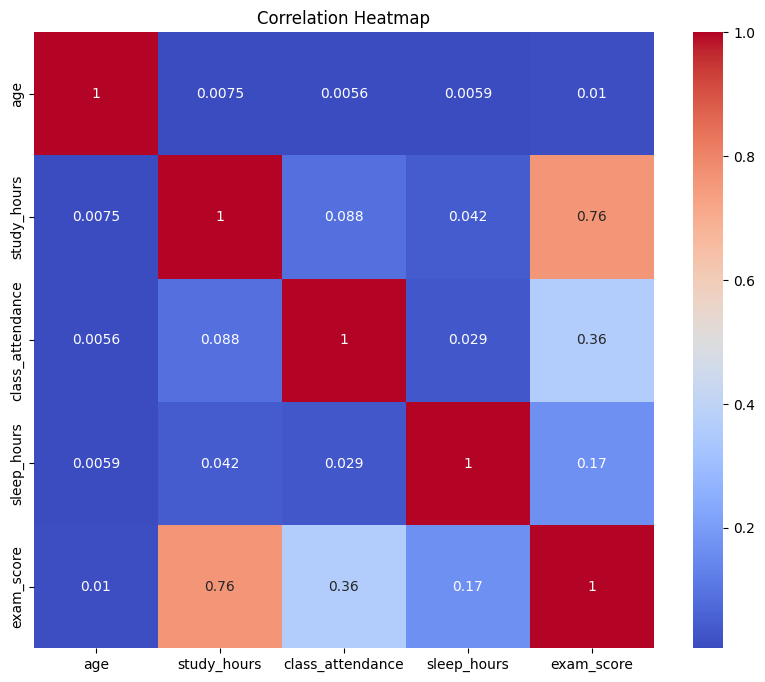

In [6]:
import matplotlib.pyplot as plt
# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')



In [9]:
df_train["exam_score"]

,exam_score
id,
0,78.300
1,46.700
2,99.000
3,63.900
4,100.000
...,...
629995,69.500
629996,78.900
629997,19.599


- daily study hours very corelated with exam score

In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
import numpy as np

# -----------------------------
# Données
# -----------------------------
df = df_train

X = df.drop(columns=["exam_score"])
y = df["exam_score"]

# Colonnes catégorielles
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# -----------------------------
# Split train / test
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Modèle CatBoost (Régression)
# -----------------------------
model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

# -----------------------------
# Entraînement
# -----------------------------
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# -----------------------------
# Évaluation
# -----------------------------
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")

# -----------------------------
# Sauvegarde
# -----------------------------
model.save_model("catboost_exam_score.cbm")


0:	learn: 18.3149907	test: 18.2447423	best: 18.2447423 (0)	total: 1.46s	remaining: 19m 25s
100:	learn: 8.8820120	test: 8.8728381	best: 8.8728381 (100)	total: 1m 18s	remaining: 9m 1s
200:	learn: 8.8392840	test: 8.8312710	best: 8.8312710 (200)	total: 2m 23s	remaining: 7m 7s
300:	learn: 8.8245759	test: 8.8194180	best: 8.8194180 (300)	total: 3m 29s	remaining: 5m 47s
400:	learn: 8.8105569	test: 8.8081792	best: 8.8081792 (400)	total: 4m 38s	remaining: 4m 36s
500:	learn: 8.7992727	test: 8.7997526	best: 8.7997411 (499)	total: 5m 46s	remaining: 3m 26s
600:	learn: 8.7905762	test: 8.7939564	best: 8.7939564 (600)	total: 6m 53s	remaining: 2m 16s
700:	learn: 8.7816426	test: 8.7872901	best: 8.7872901 (700)	total: 8m	remaining: 1m 7s
799:	learn: 8.7744055	test: 8.7825008	best: 8.7825008 (799)	total: 9m 5s	remaining: 0us

bestTest = 8.78250081
bestIteration = 799

RMSE : 8.78
MAE  : 7.01
